### Ori counts

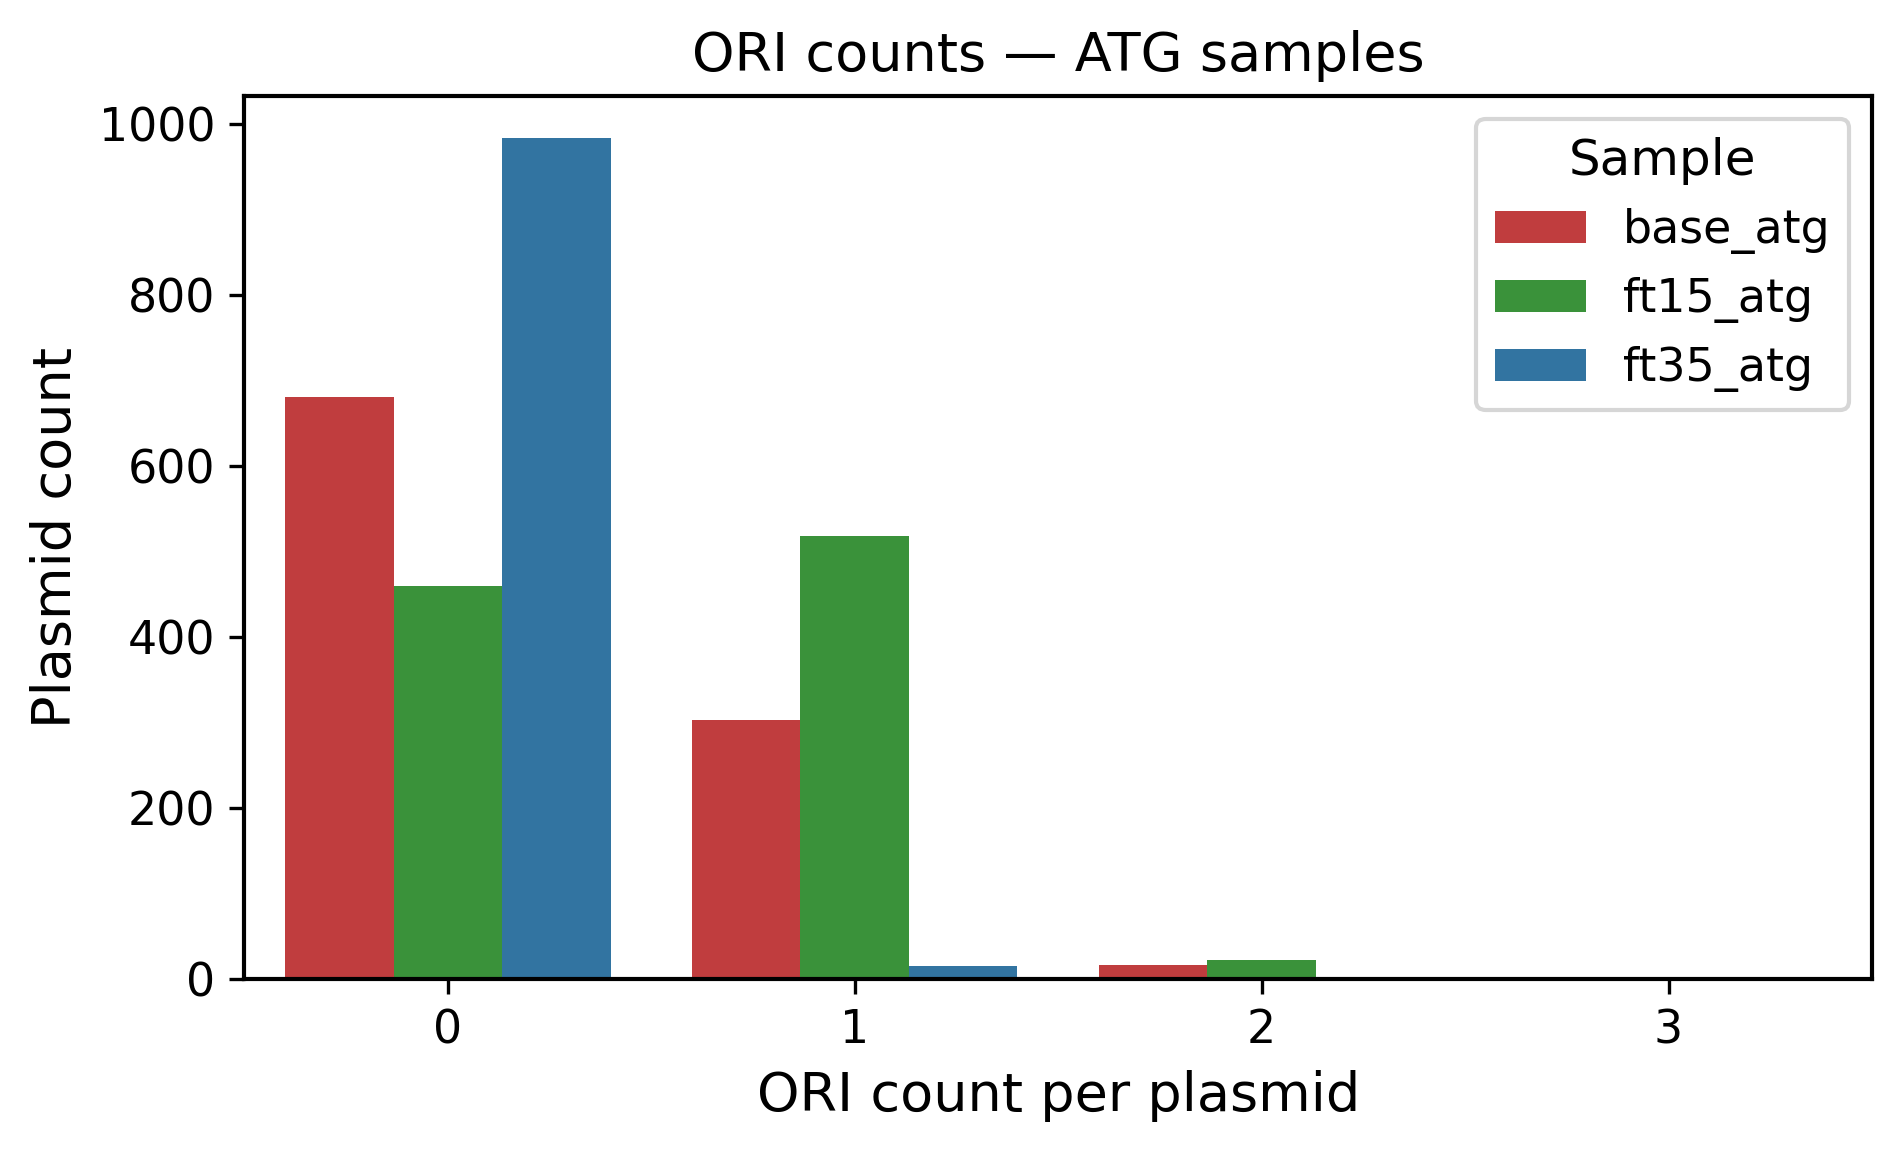

In [7]:
# --- Imports & style (safe to run multiple times) ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.size": 12, "axes.labelsize": 13, "axes.titlesize": 13,
    "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "figure.dpi": 300
})

# Locked colour mapping (keep consistent across figures)
palette_atg = {
    "base_atg": "#d62728",  # red
    "ft15_atg": "#2ca02c",  # green
    "ft35_atg": "#1f77b4",  # blue
}
hue_order_atg = ["base_atg", "ft15_atg", "ft35_atg"]

# --- Load ATG QC summaries ---
ATG_QC = {
    "base_atg": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_out_atg/qc_out_base_atg/qc_summary.csv",
    "ft15_atg": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_out_atg/qc_out_ft15_atg/qc_summary.csv",
    "ft35_atg": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_out_atg/qc_out_ft35_atg/qc_summary.csv",
}

dfs = []
for name, path in ATG_QC.items():
    df = pd.read_csv(path)
    df["dataset"] = name
    dfs.append(df)

df_atg = pd.concat(dfs, ignore_index=True)
df_atg["n_ori_kept"] = df_atg["n_ori_kept"].astype(int)

# x-axis order (0..max observed, cap at, say, 6)
max_count = int(df_atg["n_ori_kept"].max())
order_x = list(range(0, min(max_count, 6) + 1))

# --- Plot ---
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.countplot(
    data=df_atg,
    x="n_ori_kept",
    hue="dataset",
    order=order_x,
    hue_order=hue_order_atg,
    palette=palette_atg,
    ax=ax,
)

ax.set_xlabel("ORI count per plasmid")
ax.set_ylabel("Plasmid count")
ax.set_title("ORI counts — ATG samples")
ax.legend(title="Sample", loc="upper right", frameon=True)

fig.tight_layout()
fig.savefig("/cs/student/projects1/aibh/2024/acunning/Projects/figure_creations/figures/ori_counts_ATG.pdf", bbox_inches="tight")
plt.show()


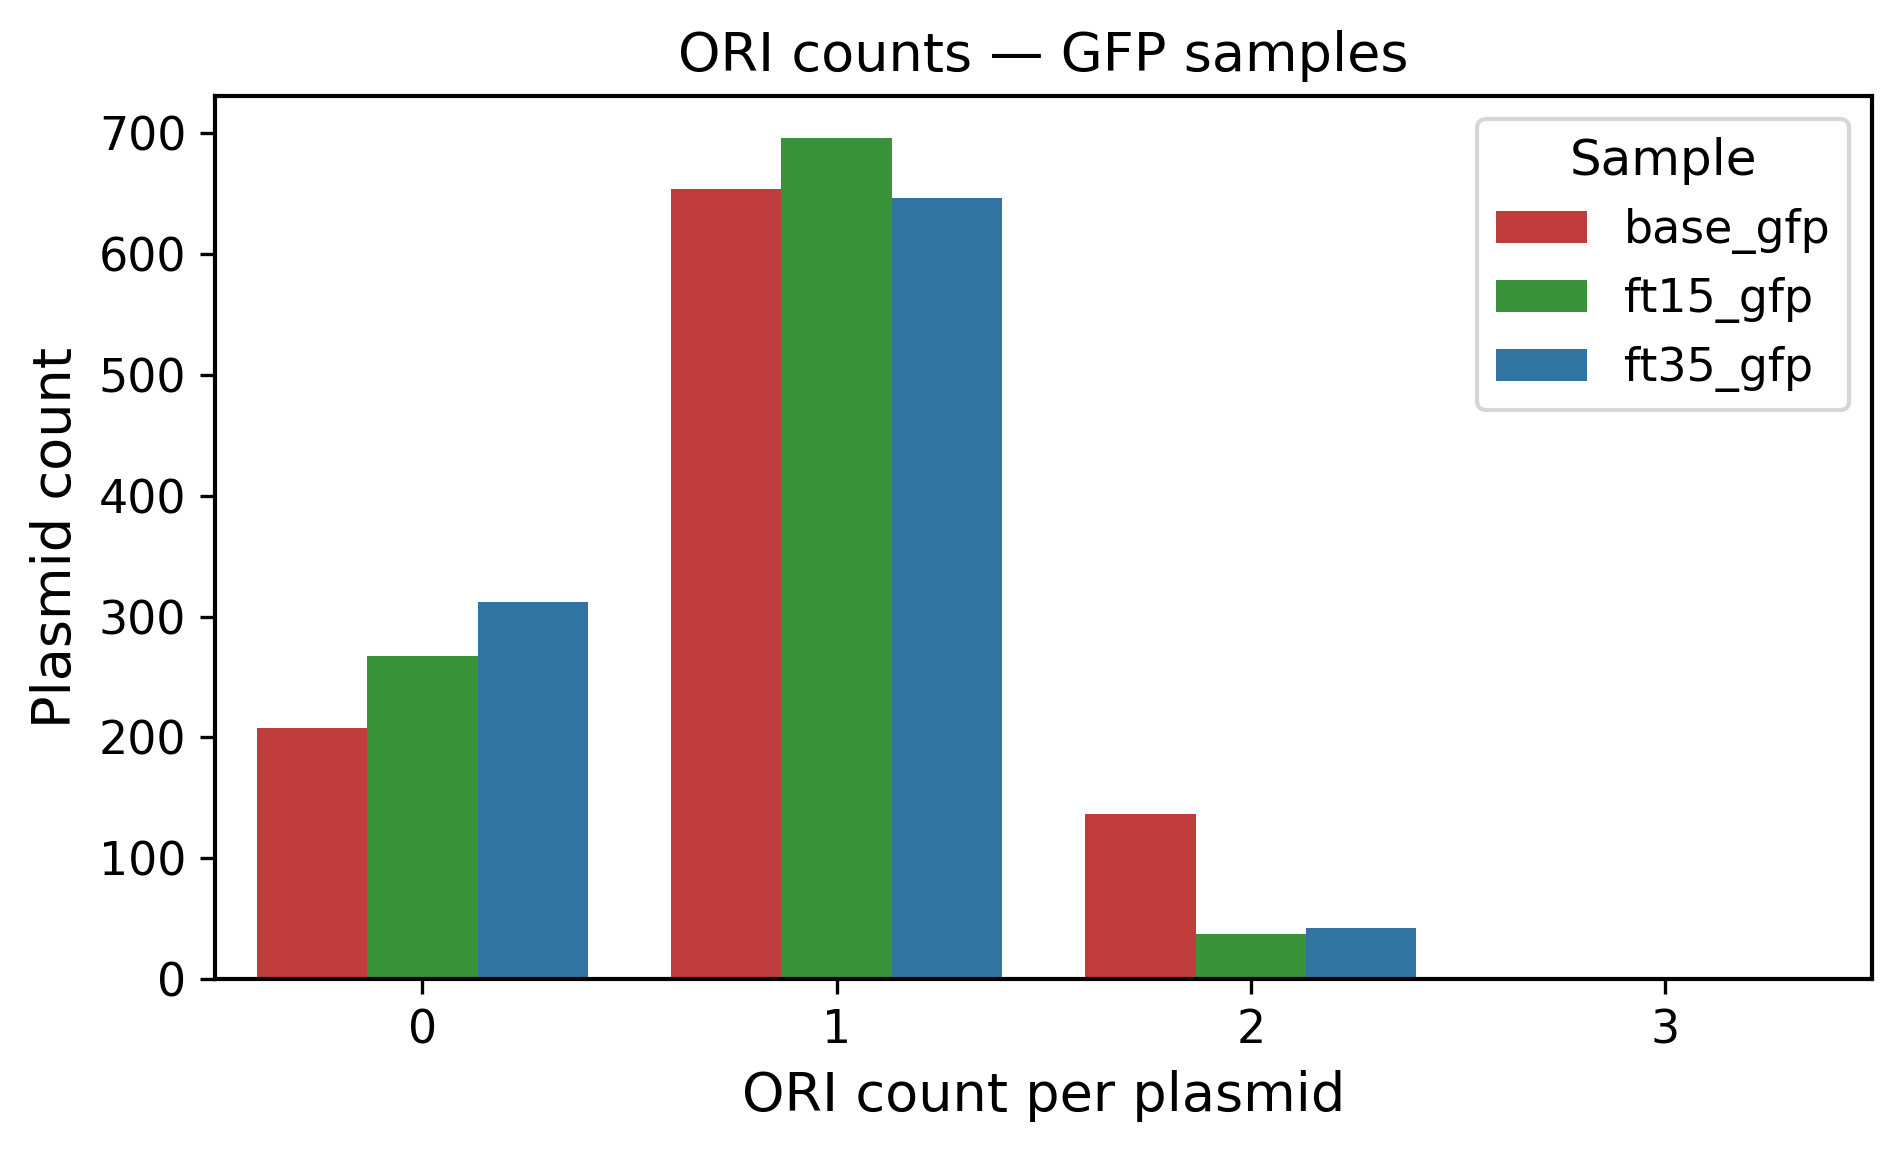

In [8]:
# Locked colour mapping (same hues = same model family)
palette_gfp = {
    "base_gfp": "#d62728",  # red
    "ft15_gfp": "#2ca02c",  # green
    "ft35_gfp": "#1f77b4",  # blue
}
hue_order_gfp = ["base_gfp", "ft15_gfp", "ft35_gfp"]

# --- Load GFP QC summaries ---
GFP_QC = {
    "base_gfp": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_out_gfp/qc_out_base/qc_summary.csv",
    "ft15_gfp": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_out_gfp/qc_out_ft15/qc_summary.csv",
    "ft35_gfp": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_out_gfp/qc_out_ft35/qc_summary.csv",
}

dfs = []
for name, path in GFP_QC.items():
    df = pd.read_csv(path)
    df["dataset"] = name
    dfs.append(df)

df_gfp = pd.concat(dfs, ignore_index=True)
df_gfp["n_ori_kept"] = df_gfp["n_ori_kept"].astype(int)

max_count = int(df_gfp["n_ori_kept"].max())
order_x = list(range(0, min(max_count, 6) + 1))

# --- Plot ---
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.countplot(
    data=df_gfp,
    x="n_ori_kept",
    hue="dataset",
    order=order_x,
    hue_order=hue_order_gfp,
    palette=palette_gfp,
    ax=ax,
)

ax.set_xlabel("ORI count per plasmid")
ax.set_ylabel("Plasmid count")
ax.set_title("ORI counts — GFP samples")
ax.legend(title="Sample", loc="upper right", frameon=True)

fig.tight_layout()
fig.savefig("/cs/student/projects1/aibh/2024/acunning/Projects/figure_creations/figures/ori_counts_GFP.pdf", bbox_inches="tight")
plt.show()


### Arg counts

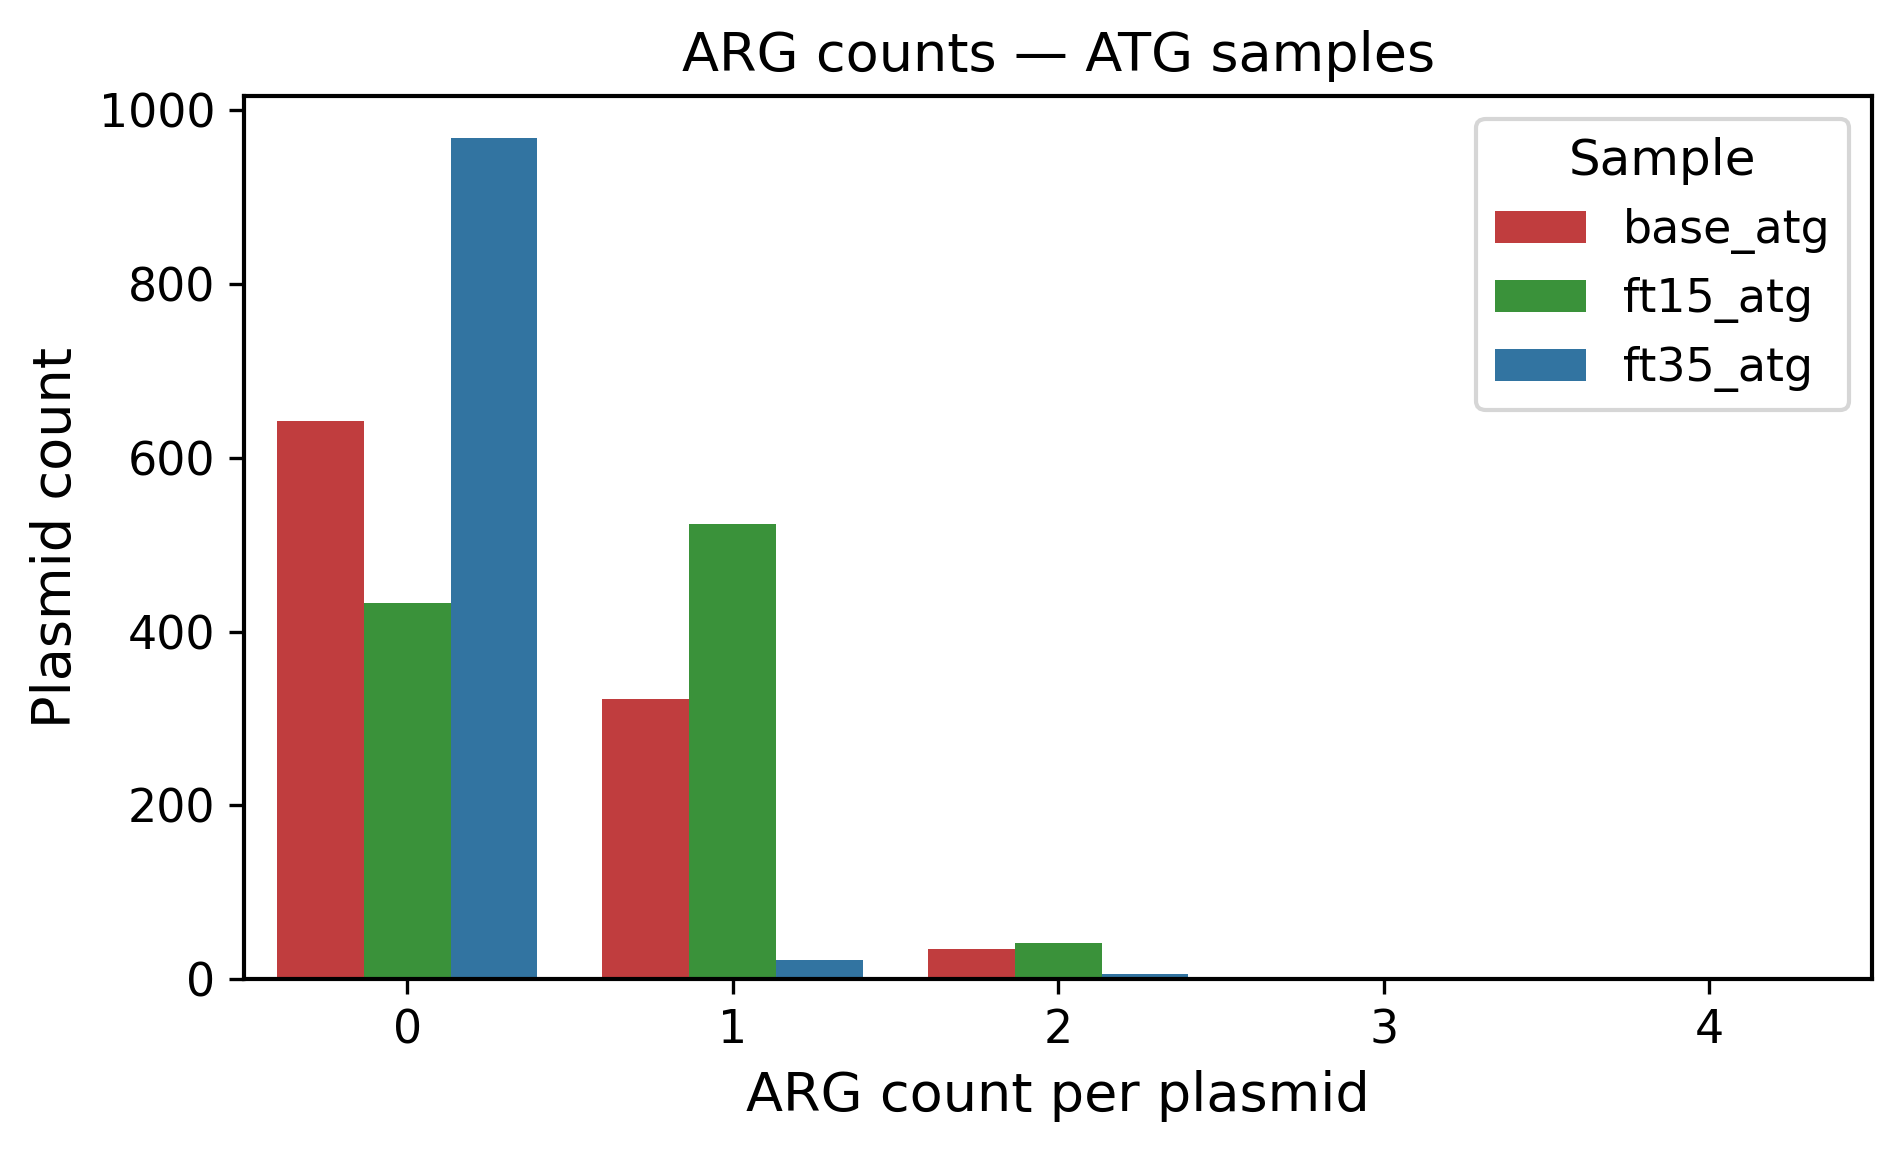

In [9]:
# Uses the same paths and style as above

# If df_atg already exists from the ORI section, you can reuse it; otherwise reload:
try:
    df_atg
except NameError:
    ATG_QC = {
        "base_atg": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_out_atg/qc_out_base_atg/qc_summary.csv",
        "ft15_atg": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_out_atg/qc_out_ft15_atg/qc_summary.csv",
        "ft35_atg": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_out_atg/qc_out_ft35_atg/qc_summary.csv",
    }
    dfs = []
    for name, path in ATG_QC.items():
        t = pd.read_csv(path)
        t["dataset"] = name
        dfs.append(t)
    df_atg = pd.concat(dfs, ignore_index=True)

# Ensure integer dtype
df_atg["n_amr"] = df_atg["n_amr"].astype(int)

# Palette/order from the ORI plot
palette_atg = {
    "base_atg": "#d62728",  # red
    "ft15_atg": "#2ca02c",  # green
    "ft35_atg": "#1f77b4",  # blue
}
hue_order_atg = ["base_atg", "ft15_atg", "ft35_atg"]

# X-axis categories (cap at 6 to keep it tidy)
max_arg = int(df_atg["n_amr"].max())
order_x = list(range(0, min(max_arg, 6) + 1))

fig, ax = plt.subplots(figsize=(6.5, 4))
sns.countplot(
    data=df_atg,
    x="n_amr",
    hue="dataset",
    order=order_x,
    hue_order=hue_order_atg,
    palette=palette_atg,
    ax=ax,
)

ax.set_xlabel("ARG count per plasmid")
ax.set_ylabel("Plasmid count")
ax.set_title("ARG counts — ATG samples")
ax.legend(title="Sample", loc="upper right", frameon=True)

# Optional: show % exactly one ARG (overall across ATG sets)
# prop_one = (df_atg["n_amr"] == 1).mean()
# ax.axvline(1, linestyle=":", color="#444444", linewidth=1)
# ax.text(1, ax.get_ylim()[1]*0.95, f"=1 ARG: {prop_one:.1%}", ha="left", va="top")

fig.tight_layout()
fig.savefig("/cs/student/projects1/aibh/2024/acunning/Projects/figure_creations/figures/arg_counts_ATG.pdf", bbox_inches="tight")
plt.show()


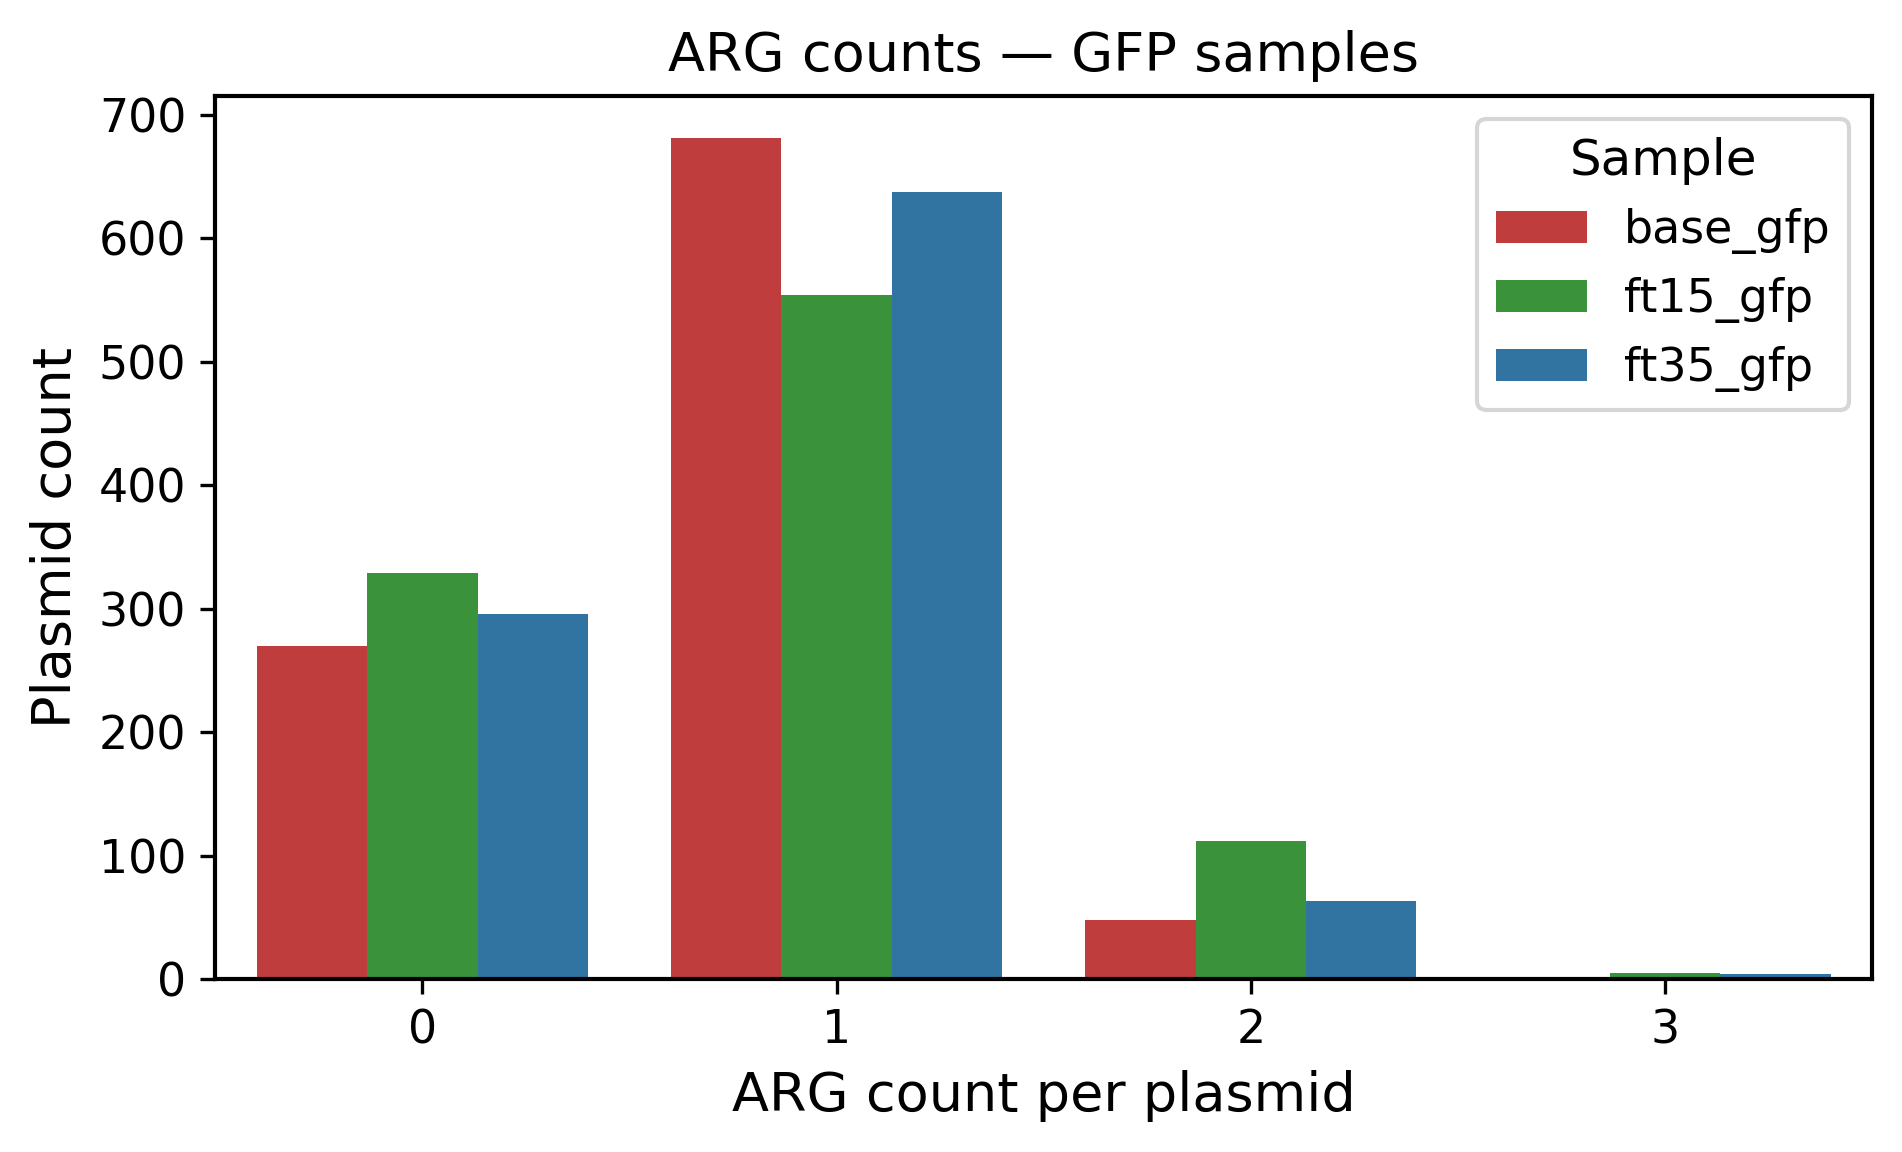

In [10]:
# Reuse df_gfp if already loaded; otherwise reload:
try:
    df_gfp
except NameError:
    GFP_QC = {
        "base_gfp": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_out_gfp/qc_out_base/qc_summary.csv",
        "ft15_gfp": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_out_gfp/qc_out_ft15/qc_summary.csv",
        "ft35_gfp": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_out_gfp/qc_out_ft35/qc_summary.csv",
    }
    dfs = []
    for name, path in GFP_QC.items():
        t = pd.read_csv(path)
        t["dataset"] = name
        dfs.append(t)
    df_gfp = pd.concat(dfs, ignore_index=True)

df_gfp["n_amr"] = df_gfp["n_amr"].astype(int)

palette_gfp = {
    "base_gfp": "#d62728",  # red
    "ft15_gfp": "#2ca02c",  # green
    "ft35_gfp": "#1f77b4",  # blue
}
hue_order_gfp = ["base_gfp", "ft15_gfp", "ft35_gfp"]

max_arg = int(df_gfp["n_amr"].max())
order_x = list(range(0, min(max_arg, 6) + 1))

fig, ax = plt.subplots(figsize=(6.5, 4))
sns.countplot(
    data=df_gfp,
    x="n_amr",
    hue="dataset",
    order=order_x,
    hue_order=hue_order_gfp,
    palette=palette_gfp,
    ax=ax,
)

ax.set_xlabel("ARG count per plasmid")
ax.set_ylabel("Plasmid count")
ax.set_title("ARG counts — GFP samples")
ax.legend(title="Sample", loc="upper right", frameon=True)

# Optional: annotate % exactly one ARG (overall across GFP sets)
# prop_one = (df_gfp["n_amr"] == 1).mean()
# ax.axvline(1, linestyle=":", color="#444444", linewidth=1)
# ax.text(1, ax.get_ylim()[1]*0.95, f"=1 ARG: {prop_one:.1%}", ha="left", va="top")

fig.tight_layout()
fig.savefig("/cs/student/projects1/aibh/2024/acunning/Projects/figure_creations/figures/arg_counts_GFP.pdf", bbox_inches="tight")
plt.show()


### Plots

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def make_radar_plot(df, group_col, value_col, title, labels, colors, outpath=None):
    """
    df: tidy dataframe with [group_col, value_col, 'count'] columns
    group_col: dataset name
    value_col: ARG symbol
    labels: list of ARG symbols (top N)
    colors: dict of {dataset: color}
    """
    N = len(labels)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the polygon

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

    for dataset, color in colors.items():
        sub = df[df[group_col] == dataset].set_index(value_col)["count"]
        values = [sub.get(l, 0) for l in labels]
        values += values[:1]  # close loop
        ax.plot(angles, values, label=dataset, color=color, linewidth=2)
        ax.fill(angles, values, color=color, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title(title, size=14)
    ax.legend(loc="upper right", bbox_to_anchor=(1.1, 1.1))
    fig.tight_layout()
    if outpath:
        fig.savefig(outpath, bbox_inches="tight")
    plt.show()
    return fig, ax


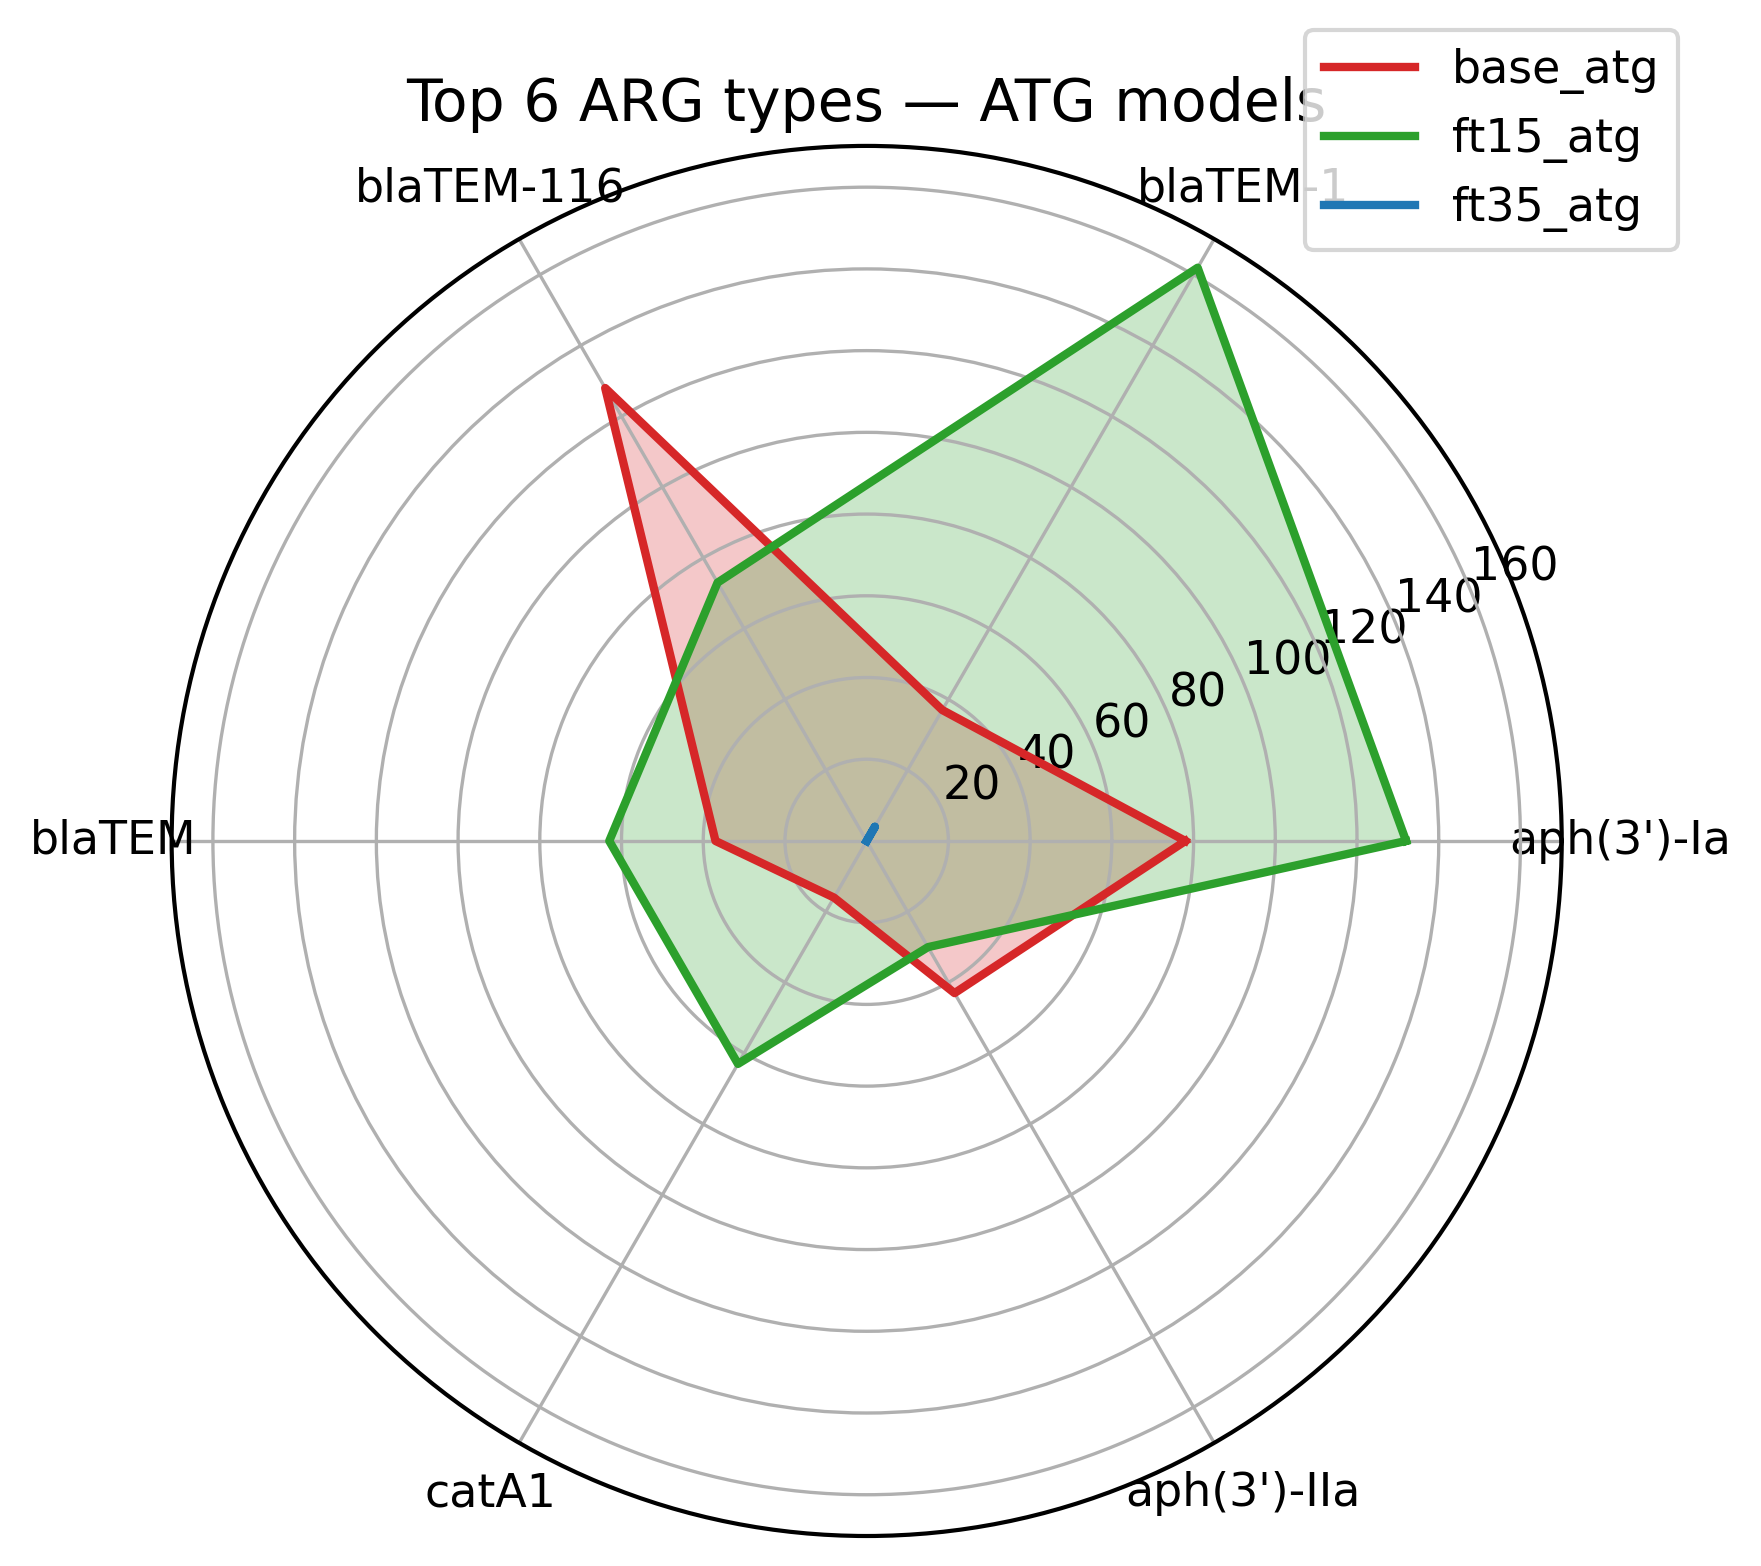

(<Figure size 1800x1800 with 1 Axes>,
 <PolarAxes: title={'center': 'Top 6 ARG types — ATG models'}>)

In [12]:
# Paths to aggregate ARG calls
ATG_AMR = {
    "base_atg": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_out_atg/qc_out_base_atg/aggregate_amr_calls.csv",
    "ft15_atg": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_out_atg/qc_out_ft15_atg/aggregate_amr_calls.csv",
    "ft35_atg": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_out_atg/qc_out_ft35_atg/aggregate_amr_calls.csv",
}

dfs = []
for name, path in ATG_AMR.items():
    df = pd.read_csv(path)
    df["dataset"] = name
    dfs.append(df)
df_atg = pd.concat(dfs, ignore_index=True)

# Count ARG symbols
counts = df_atg.groupby(["dataset","symbol"]).size().reset_index(name="count")

# Identify top 6 ARG symbols overall
top6 = counts.groupby("symbol")["count"].sum().nlargest(6).index.tolist()

# Subset to top6
counts_top6 = counts[counts["symbol"].isin(top6)]

# Colors and plot
palette_atg = {"base_atg":"#d62728","ft15_atg":"#2ca02c","ft35_atg":"#1f77b4"}
make_radar_plot(
    counts_top6, group_col="dataset", value_col="symbol",
    title="Top 6 ARG types — ATG models",
    labels=top6, colors=palette_atg,
    outpath=Path("fig_4_15_top6_arg_ATG.pdf")
)


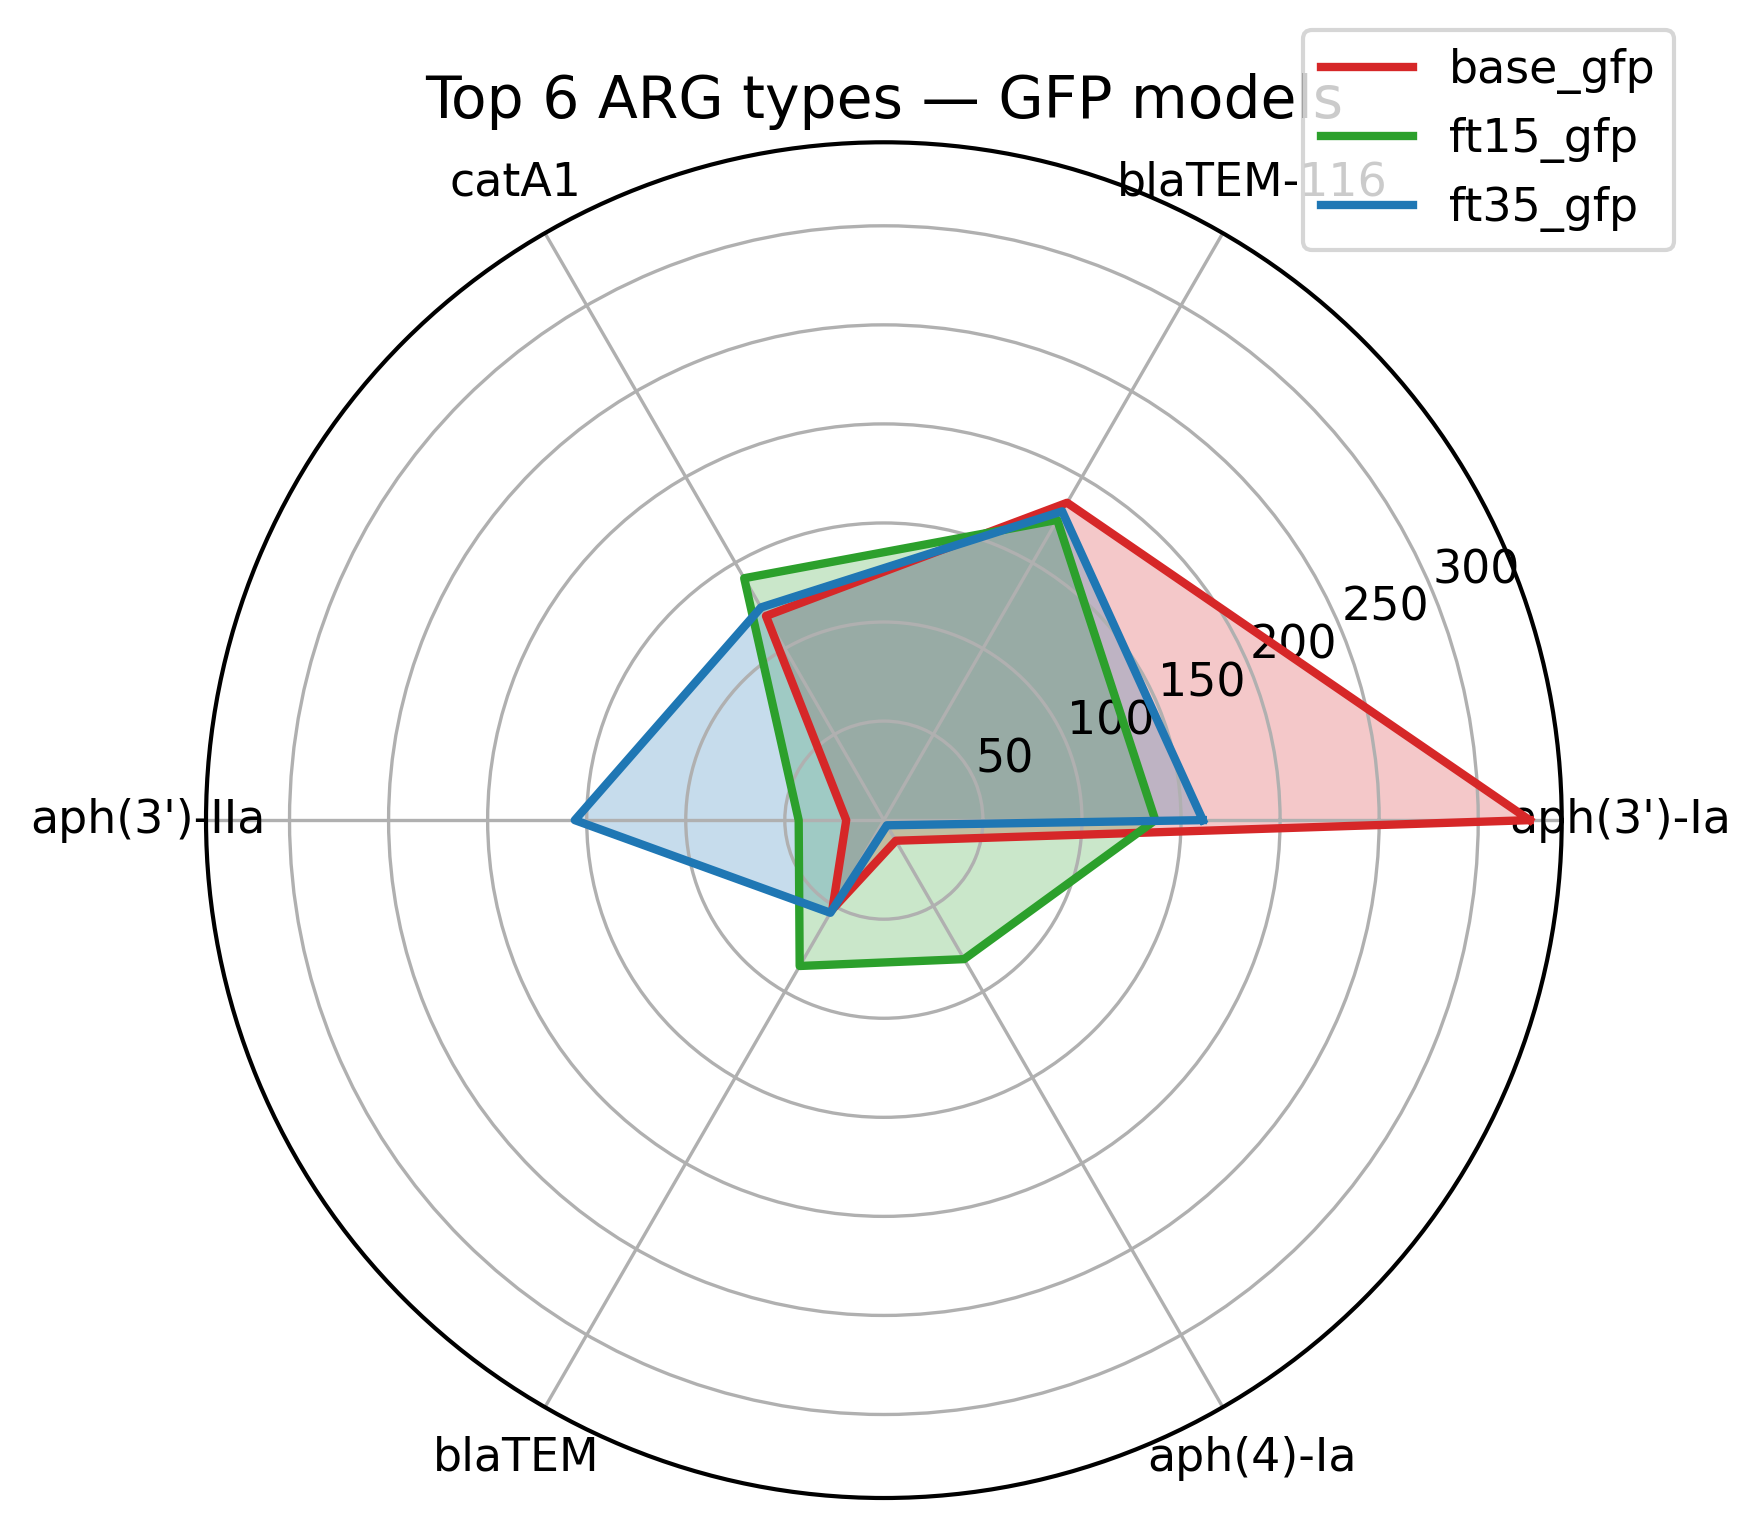

(<Figure size 1800x1800 with 1 Axes>,
 <PolarAxes: title={'center': 'Top 6 ARG types — GFP models'}>)

In [13]:
GFP_AMR = {
    "base_gfp": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_out_gfp/qc_out_base/aggregate_amr_calls.csv",
    "ft15_gfp": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_out_gfp/qc_out_ft15/aggregate_amr_calls.csv",
    "ft35_gfp": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_out_gfp/qc_out_ft35/aggregate_amr_calls.csv",
}

dfs = []
for name, path in GFP_AMR.items():
    df = pd.read_csv(path)
    df["dataset"] = name
    dfs.append(df)
df_gfp = pd.concat(dfs, ignore_index=True)

counts = df_gfp.groupby(["dataset","symbol"]).size().reset_index(name="count")
top6 = counts.groupby("symbol")["count"].sum().nlargest(6).index.tolist()
counts_top6 = counts[counts["symbol"].isin(top6)]

palette_gfp = {"base_gfp":"#d62728","ft15_gfp":"#2ca02c","ft35_gfp":"#1f77b4"}
make_radar_plot(
    counts_top6, group_col="dataset", value_col="symbol",
    title="Top 6 ARG types — GFP models",
    labels=top6, colors=palette_gfp,
    outpath=Path("fig_4_15_top6_arg_GFP.pdf")
)


In [15]:
import re

# Compile patterns with properly escaped parentheses
GROUP_RULES = [
    (re.compile(r"^blaTEM", re.I),  "blaTEM"),
    (re.compile(r"^blaOXA", re.I),  "blaOXA"),
    (re.compile(r"^blaCTX", re.I),  "blaCTX"),
    (re.compile(r"^aph\(3'\)", re.I), "aph(3')"),
    (re.compile(r"^aph\(6\)", re.I),  "aph(6)"),
    (re.compile(r"^aac\(", re.I),   "aac"),
    (re.compile(r"^aadA", re.I),    "aadA"),
    (re.compile(r"^tet", re.I),     "tet"),
    (re.compile(r"^sul", re.I),     "sul"),
    (re.compile(r"^erm", re.I),     "erm"),
]

def group_symbol(symbol: str) -> str:
    if not isinstance(symbol, str):
        return symbol
    s = symbol.strip()
    # Try explicit families first
    for pat, fam in GROUP_RULES:
        if pat.search(s):
            return fam
    # Keep aph(...) family form if present
    m = re.match(r"^(aph\(\d+'?\))", s, flags=re.I)
    if m:
        return m.group(1)
    # Generic fallback: take chunk before first '-', '_', or space
    base = re.split(r"[-_\s]", s)[0]
    return base


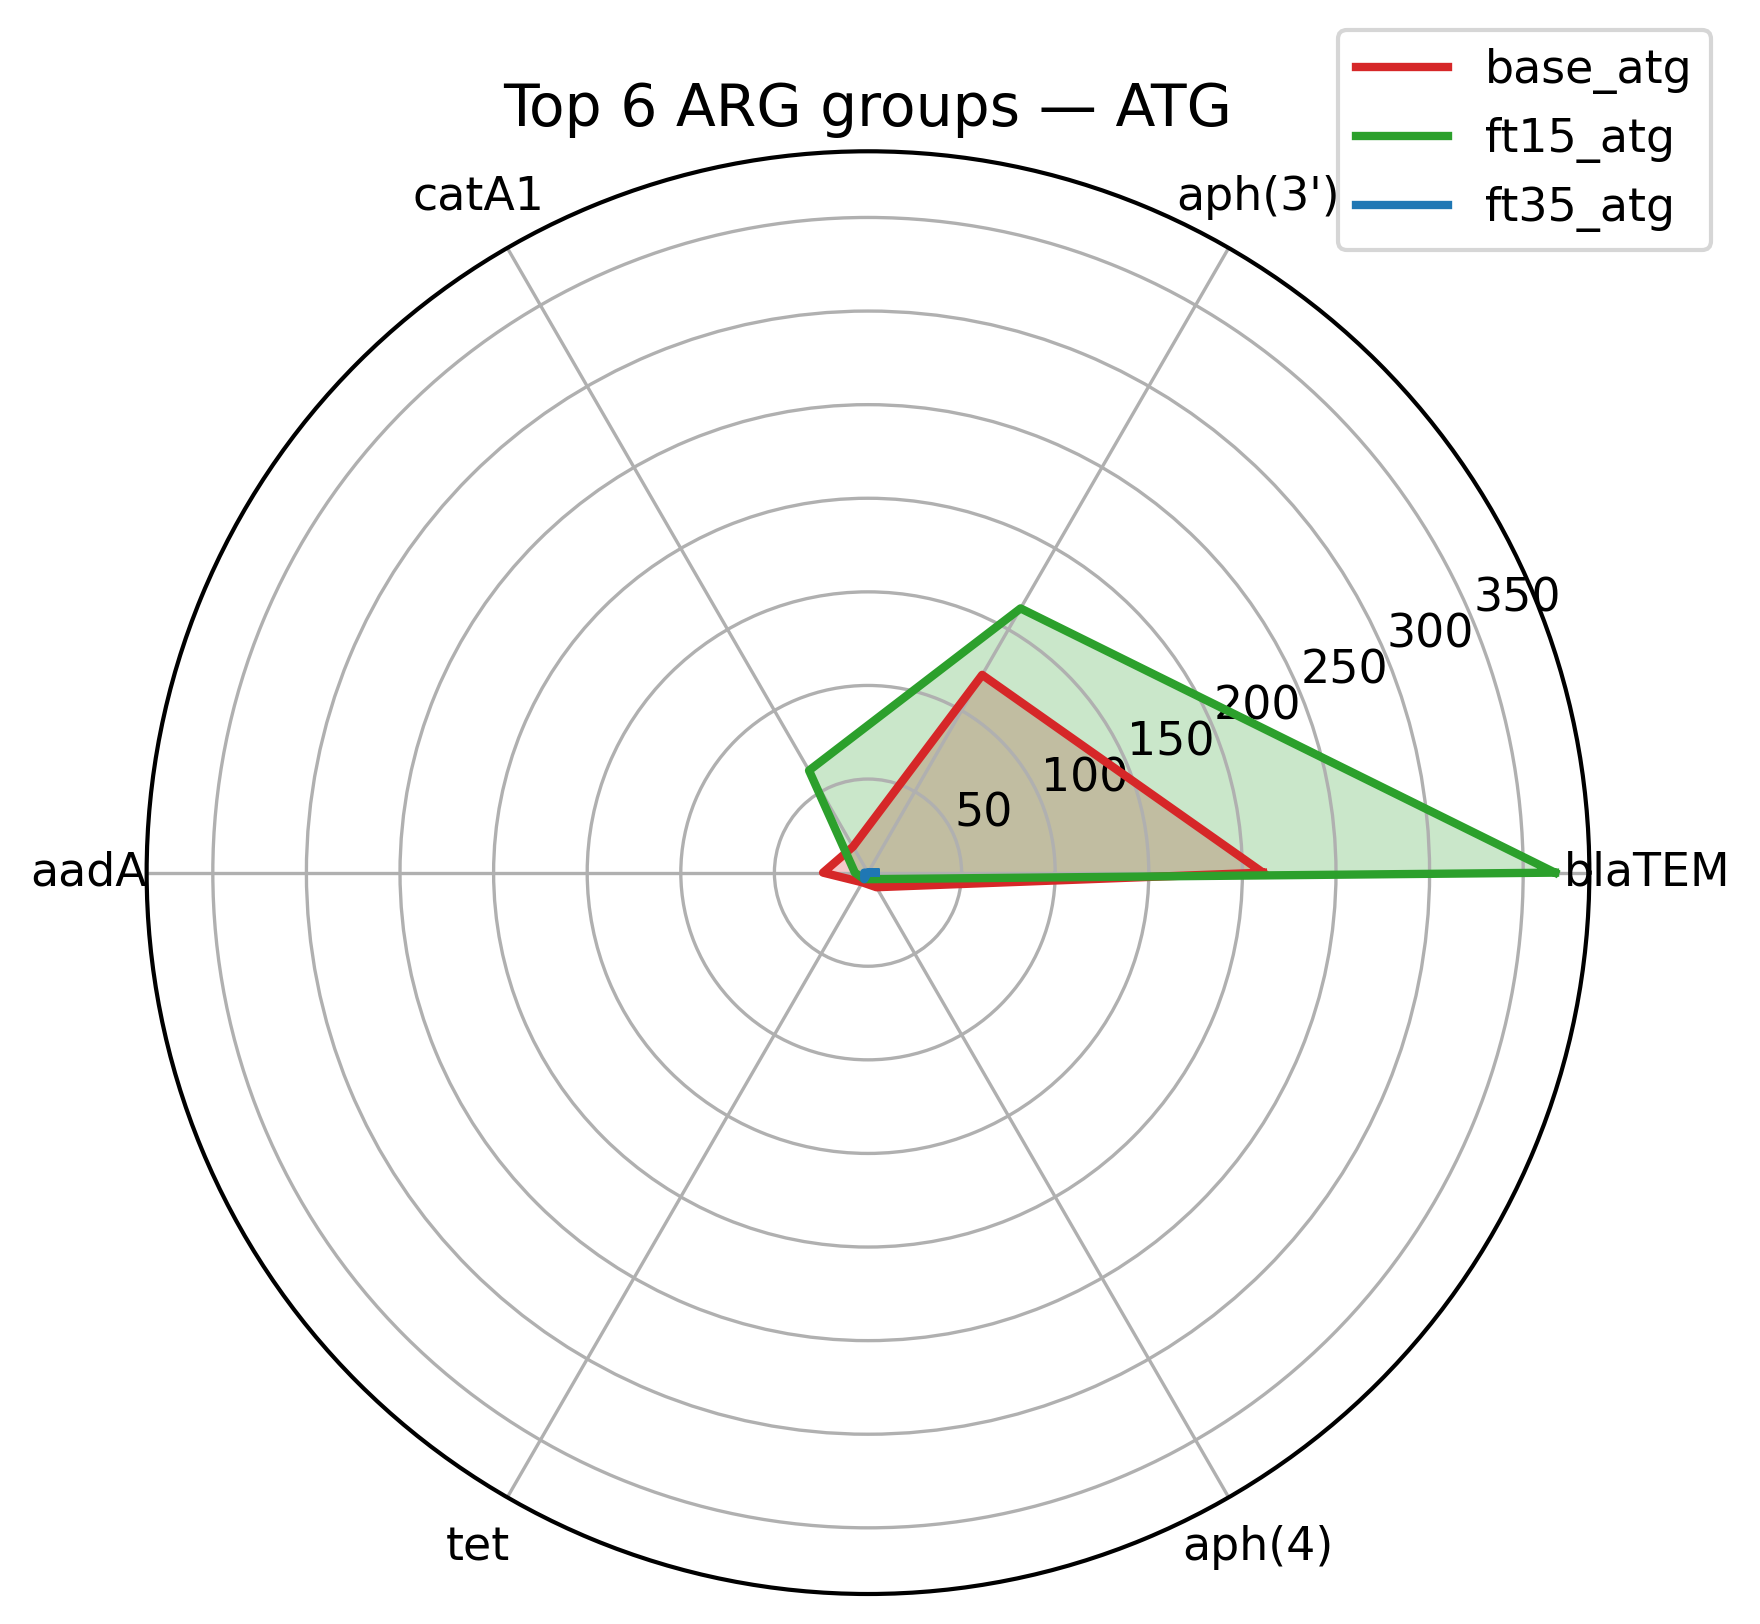

(<Figure size 1800x1800 with 1 Axes>,
 <PolarAxes: title={'center': 'Top 6 ARG groups — ATG'}>)

In [19]:
# Expect df_atg with columns: sequence, symbol, name, start, end, ..., and df_atg["dataset"] already set
df_atg["symbol_grouped"] = df_atg["symbol"].map(group_symbol)

counts_atg = (
    df_atg.groupby(["dataset", "symbol_grouped"])
          .size().reset_index(name="count")
)

# Top 6 groups overall across ATG
top6_atg = (
    counts_atg.groupby("symbol_grouped")["count"]
    .sum().nlargest(6).index.tolist()
)
counts_atg_top6 = counts_atg[counts_atg["symbol_grouped"].isin(top6_atg)]

palette_atg = {"base_atg":"#d62728","ft15_atg":"#2ca02c","ft35_atg":"#1f77b4"}

make_radar_plot(
    counts_atg_top6, group_col="dataset", value_col="symbol_grouped",
    title="Top 6 ARG groups — ATG",
    labels=top6_atg, colors=palette_atg,
    outpath=Path("/cs/student/projects1/aibh/2024/acunning/Projects/figure_creations/figures/arg_grouped_ATG.pdf")
)


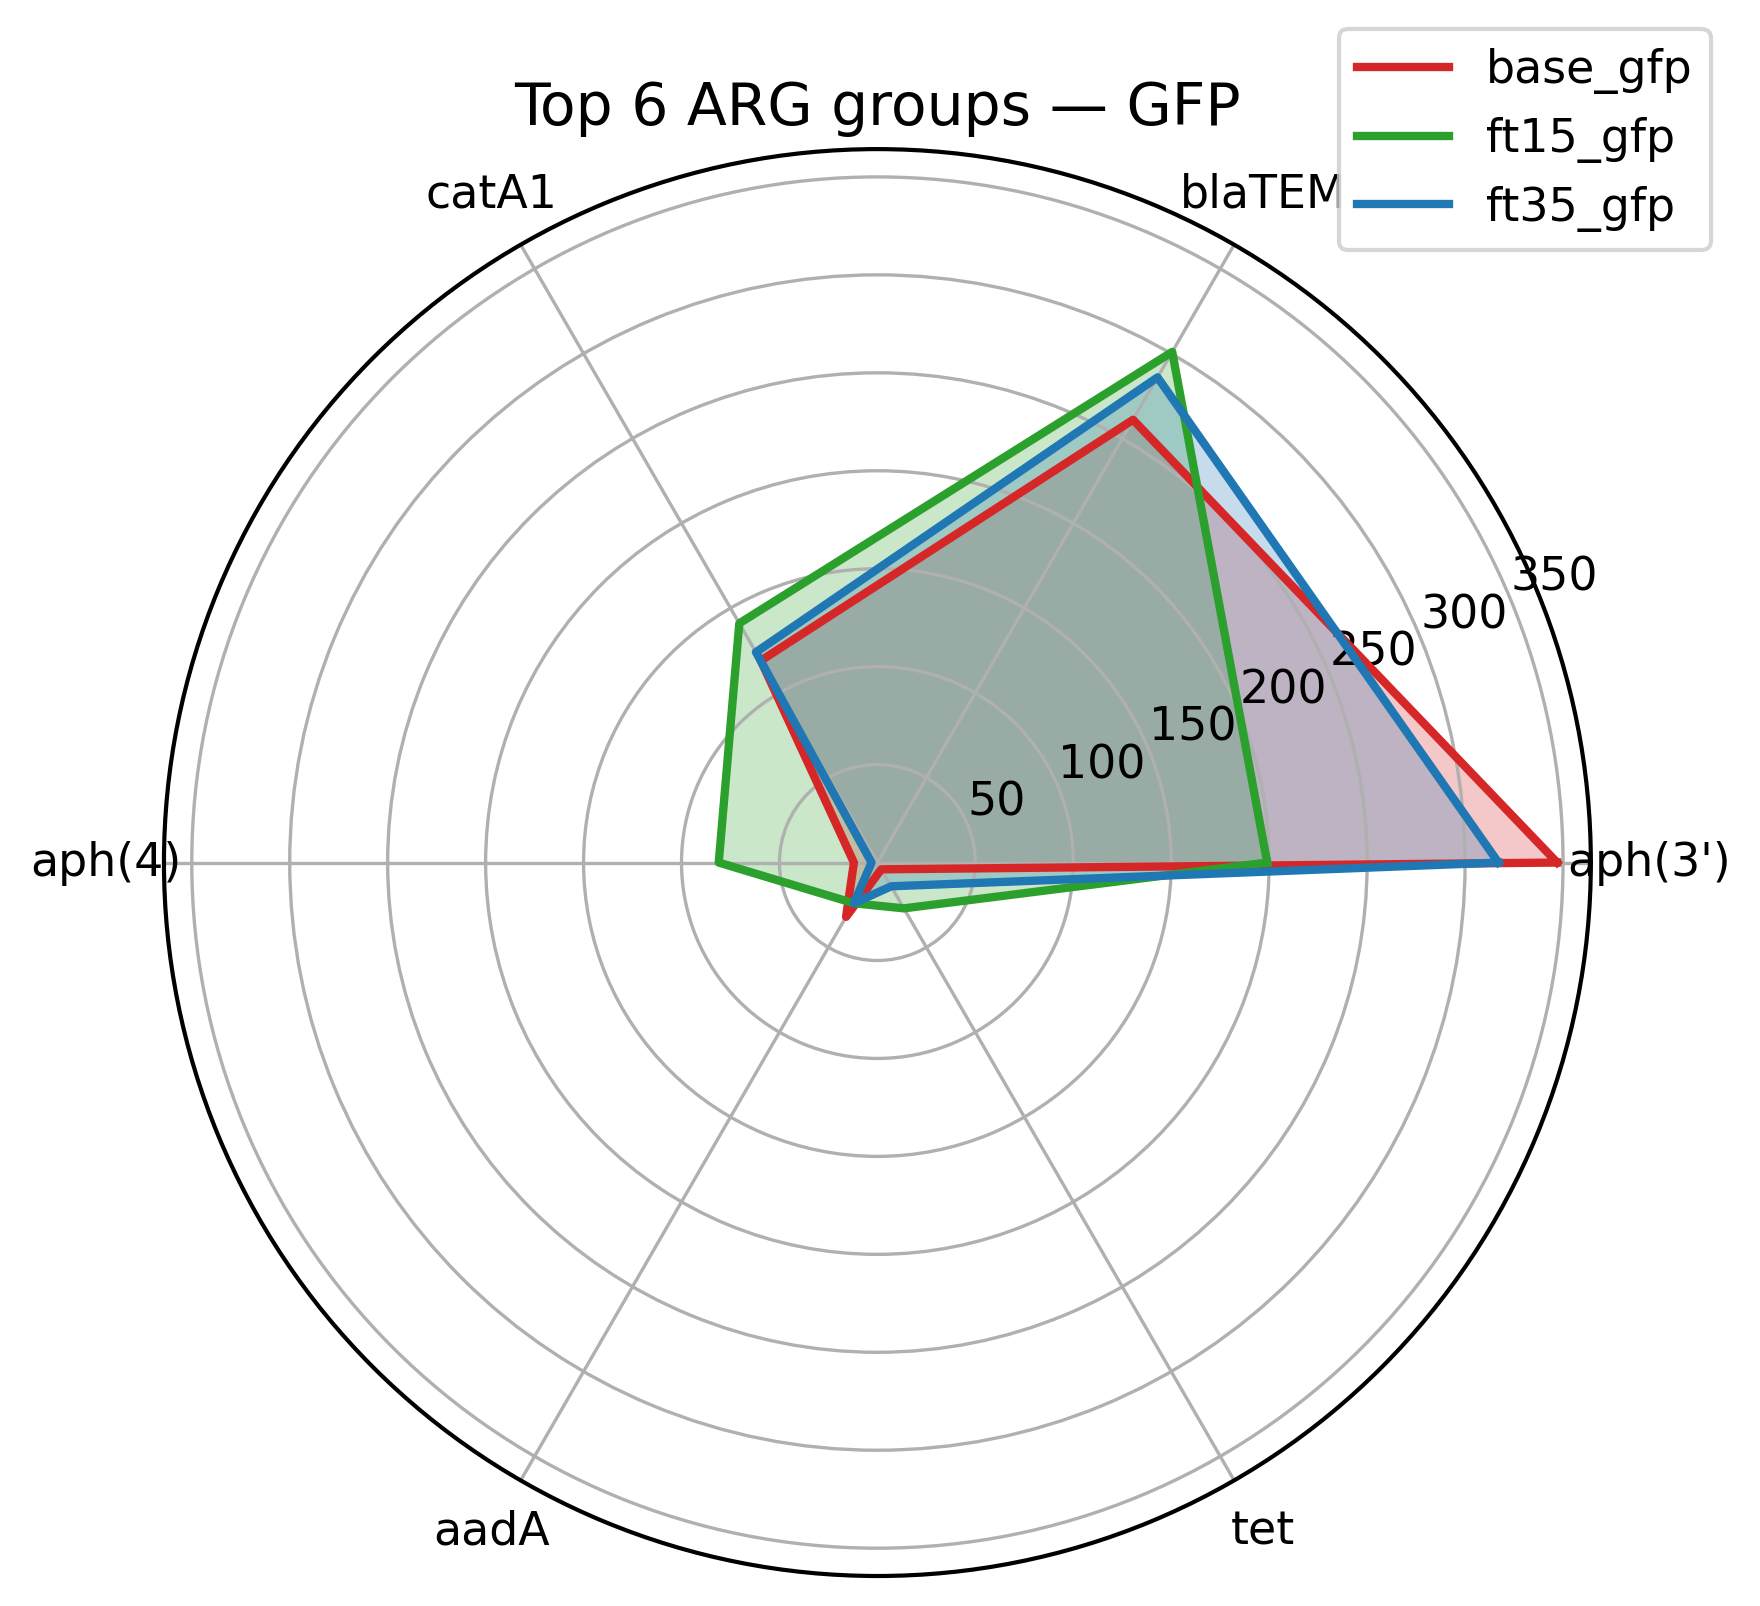

(<Figure size 1800x1800 with 1 Axes>,
 <PolarAxes: title={'center': 'Top 6 ARG groups — GFP'}>)

In [20]:
# Expect df_gfp (same columns) and df_gfp["dataset"] already set
df_gfp["symbol_grouped"] = df_gfp["symbol"].map(group_symbol)

counts_gfp = (
    df_gfp.groupby(["dataset", "symbol_grouped"])
          .size().reset_index(name="count")
)

top6_gfp = (
    counts_gfp.groupby("symbol_grouped")["count"]
    .sum().nlargest(6).index.tolist()
)
counts_gfp_top6 = counts_gfp[counts_gfp["symbol_grouped"].isin(top6_gfp)]

palette_gfp = {"base_gfp":"#d62728","ft15_gfp":"#2ca02c","ft35_gfp":"#1f77b4"}

make_radar_plot(
    counts_gfp_top6, group_col="dataset", value_col="symbol_grouped",
    title="Top 6 ARG groups — GFP",
    labels=top6_gfp, colors=palette_gfp,
    outpath=Path("/cs/student/projects1/aibh/2024/acunning/Projects/figure_creations/figures/arg_grouped_GFP.pdf")
)
